# 1) Reading Dataset
---

Step 0: Importing necessary modules

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Step 1: Loading Factory dataset

Dataset source : https://www.kaggle.com/datasets/canozensoy/industrial-iot-dataset-synthetic

In [2]:
import os
import kagglehub

# Download the dataset from Kaggle and load the CSV directly
path = kagglehub.dataset_download('canozensoy/industrial-iot-dataset-synthetic')
csv_path = os.path.join(path, 'factory_sensor_simulator_2040.csv')
df = pd.read_csv(csv_path)

c:\Users\Ahmed\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Step 2: Displaying rows & understanding the data

In [3]:
df

,Machine_ID,Machine_Type,Installation_Year,Operational_Hours,Temperature_C,Vibration_mms,Sound_dB,Oil_Level_pct,Coolant_Level_pct,Power_Consumption_kW,...,Failure_History_Count,AI_Supervision,Error_Codes_Last_30_Days,Remaining_Useful_Life_days,Failure_Within_7_Days,Laser_Intensity,Hydraulic_Pressure_bar,Coolant_Flow_L_min,Heat_Index,AI_Override_Events
0,MC_000000,Mixer,2027,81769,73.43,12.78,83.72,36.76,68.74,84.95,...,5,True,3,162.0,False,NaN,NaN,NaN,NaN,2
1,MC_000001,Industrial_Chiller,2032,74966,58.32,14.99,77.04,100.00,62.13,154.61,...,2,True,4,147.0,False,NaN,NaN,40.92,NaN,2
2,MC_000002,Pick_and_Place,2003,94006,49.63,23.78,69.08,42.96,35.96,51.90,...,1,True,6,0.0,True,NaN,NaN,NaN,NaN,2
3,MC_000003,Vision_System,2007,76637,63.73,12.38,85.58,94.90,48.94,75.61,...,1,False,4,161.0,False,NaN,NaN,NaN,NaN,0
4,MC_000004,Shuttle_System,2016,20870,42.77,4.42,96.72,47.56,53.78,224.93,...,2,False,1,765.0,False,NaN,NaN,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499995,MC_499995,Vacuum_Packer,2011,14425,65.42,16.50,81.95,59.21,73.67,255.87,...,3,False,0,820.0,False,NaN,NaN,NaN,NaN,0
499996,MC_499996,Conveyor_Belt,2003,75501,44.83,12.88,64.94,73.69,29.25,198.37,...,1,False,4,34.0,False,NaN,NaN,NaN,NaN,0
499997,MC_499997,CMM,2039,19855,37.26,11.46,70.70,70.70,49.04,156.59,...,2,False,4,815.0,False,NaN,NaN,NaN,NaN,0
499998,MC_499998,Dryer,2035,86823,67.72,16.76,77.45,97.00,15.40,132.33,...,2,True,0,99.0,False,NaN,NaN,NaN,NaN,2


In [4]:
df[['Last_Maintenance_Days_Ago', 'Maintenance_History_Count']]

,Last_Maintenance_Days_Ago,Maintenance_History_Count
0,153,4
1,136,5
2,258,1
3,43,4
4,346,4
...,...,...
499995,282,4
499996,208,4
499997,185,7
499998,274,3


Step 3: Statistics & other information about the data

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Installation_Year,500000.0,2019.962360,11.829812,2000.00,2010.00,2020.00,2030.0000,2040.00
Operational_Hours,500000.0,50012.424764,28861.849078,0.00,25055.00,49973.00,74995.0000,100000.00
Temperature_C,500000.0,59.997682,14.986973,-15.73,49.89,60.00,70.0500,127.33
Vibration_mms,500000.0,9.991140,4.999530,-17.82,6.62,10.00,13.3600,32.47
Sound_dB,500000.0,75.003477,9.990791,23.65,68.27,75.00,81.7300,120.70
Oil_Level_pct,500000.0,69.456568,18.847444,0.00,56.54,70.03,83.5400,100.00
Coolant_Level_pct,500000.0,64.114159,23.152998,0.00,48.13,65.01,81.8400,100.00
Power_Consumption_kW,500000.0,149.922161,79.955937,-222.74,96.09,149.95,203.9000,544.20
Last_Maintenance_Days_Ago,500000.0,182.257866,105.552537,0.00,91.00,182.00,274.0000,365.00
Maintenance_History_Count,500000.0,5.003128,2.238043,0.00,3.00,5.00,6.0000,18.00


In [6]:
df[['Laser_Intensity', 'Hydraulic_Pressure_bar', 'Coolant_Flow_L_min', 'Heat_Index']].isna().sum()

Laser_Intensity           484844
Hydraulic_Pressure_bar    469660
Coolant_Flow_L_min        454376
Heat_Index                454786
dtype: int64

In [7]:
df.shape

(500000, 22)

In [8]:
df.columns # 22 initial columns

Index(['Machine_ID', 'Machine_Type', 'Installation_Year', 'Operational_Hours',
       'Temperature_C', 'Vibration_mms', 'Sound_dB', 'Oil_Level_pct',
       'Coolant_Level_pct', 'Power_Consumption_kW',
       'Last_Maintenance_Days_Ago', 'Maintenance_History_Count',
       'Failure_History_Count', 'AI_Supervision', 'Error_Codes_Last_30_Days',
       'Remaining_Useful_Life_days', 'Failure_Within_7_Days',
       'Laser_Intensity', 'Hydraulic_Pressure_bar', 'Coolant_Flow_L_min',
       'Heat_Index', 'AI_Override_Events'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 22 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Machine_ID                  500000 non-null  object 
 1   Machine_Type                500000 non-null  object 
 2   Installation_Year           500000 non-null  int64  
 3   Operational_Hours           500000 non-null  int64  
 4   Temperature_C               500000 non-null  float64
 5   Vibration_mms               500000 non-null  float64
 6   Sound_dB                    500000 non-null  float64
 7   Oil_Level_pct               500000 non-null  float64
 8   Coolant_Level_pct           500000 non-null  float64
 9   Power_Consumption_kW        500000 non-null  float64
 10  Last_Maintenance_Days_Ago   500000 non-null  int64  
 11  Maintenance_History_Count   500000 non-null  int64  
 12  Failure_History_Count       500000 non-null  int64  
 13  AI_Supervision

## Step 4: Visuals

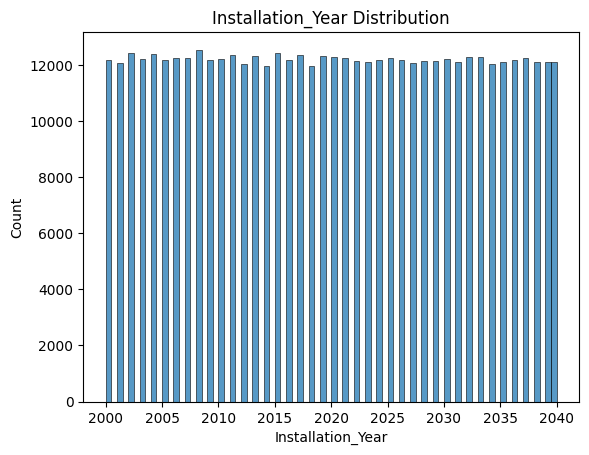

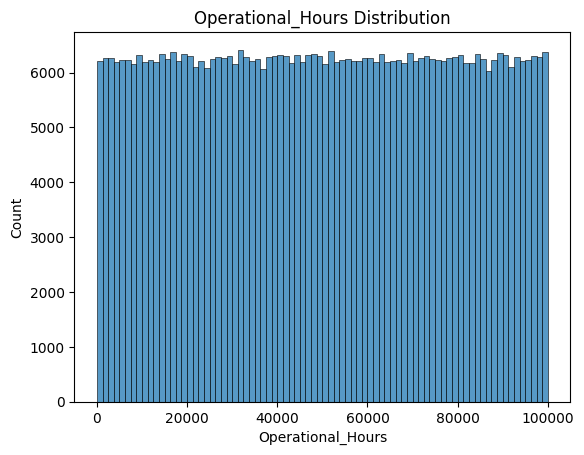

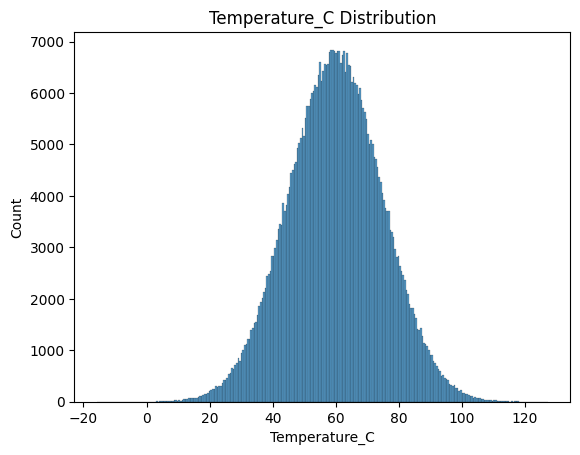

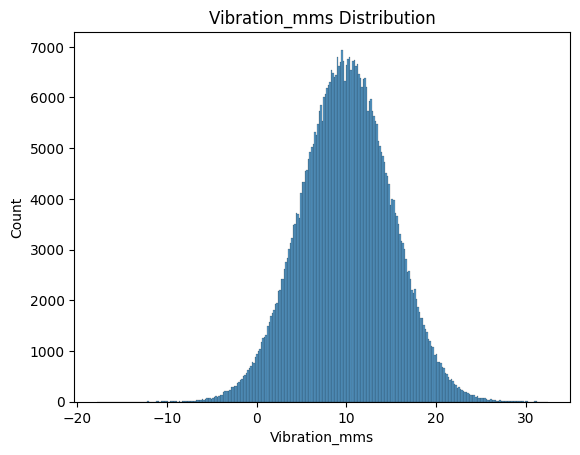

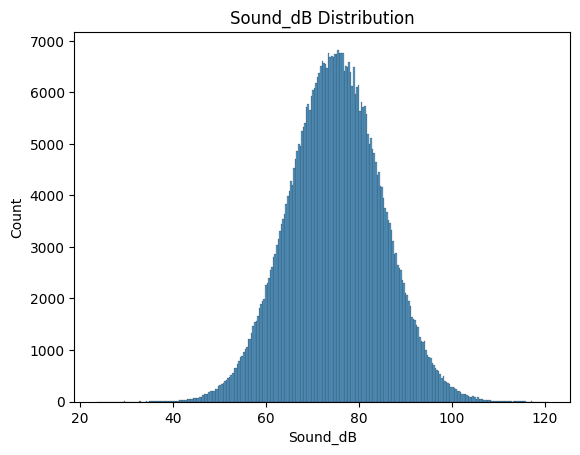

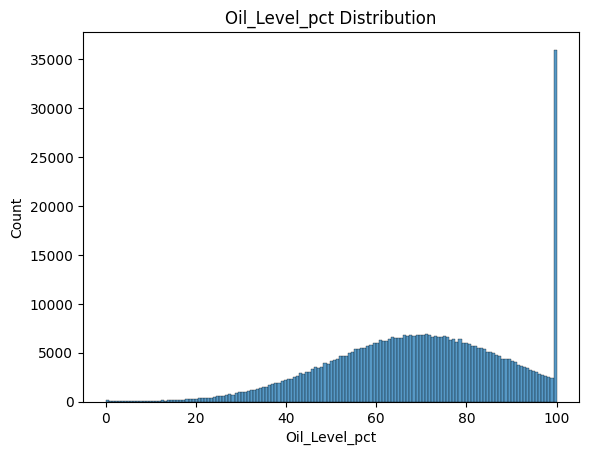

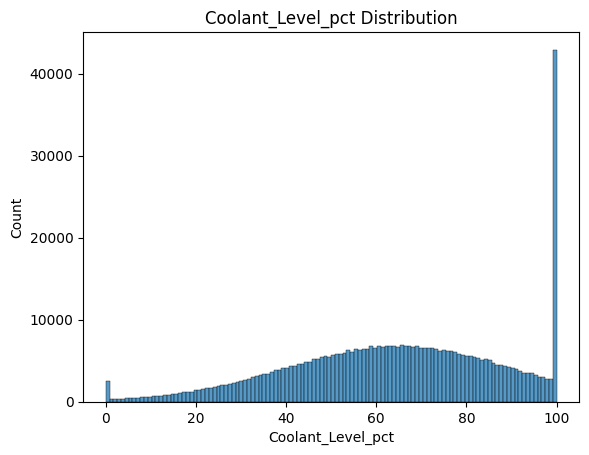

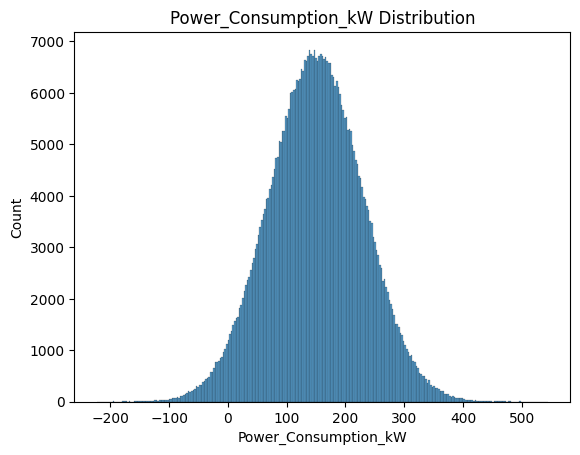

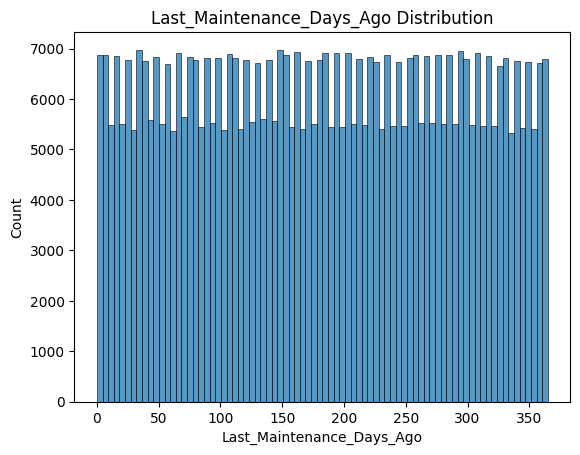

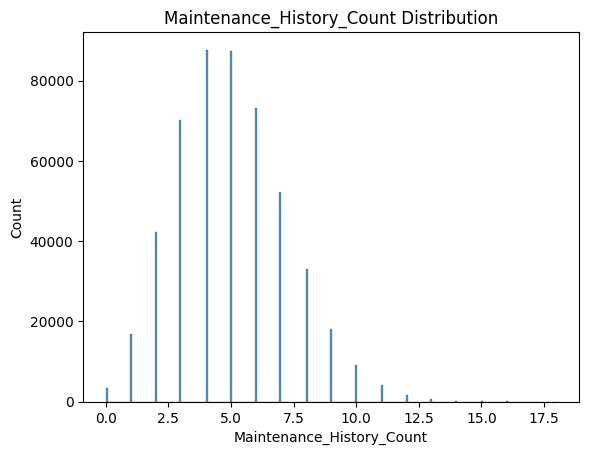

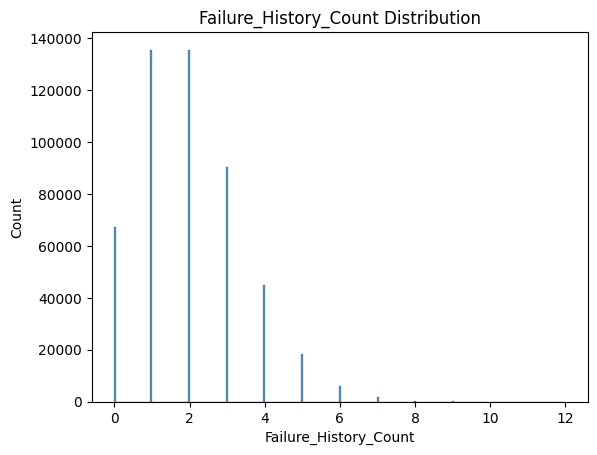

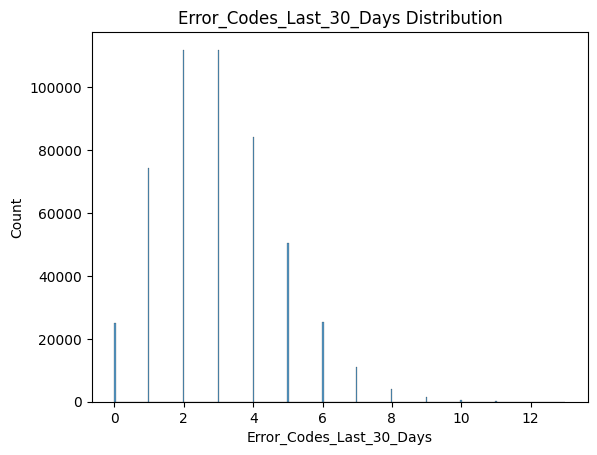

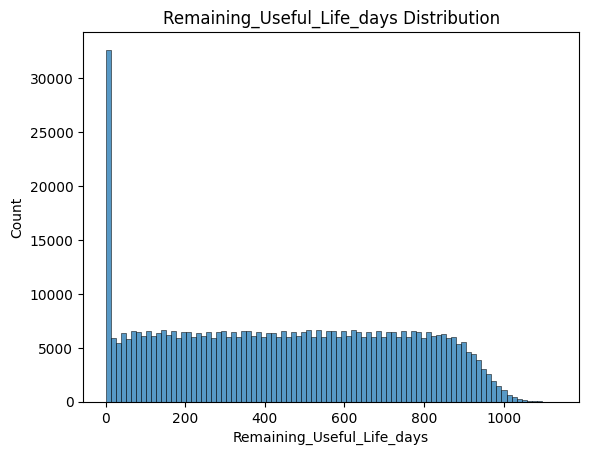

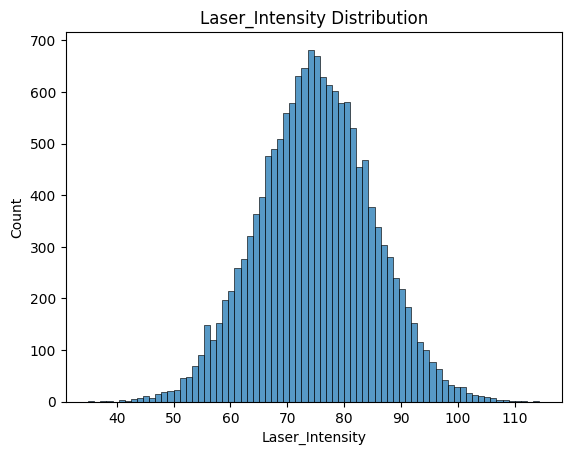

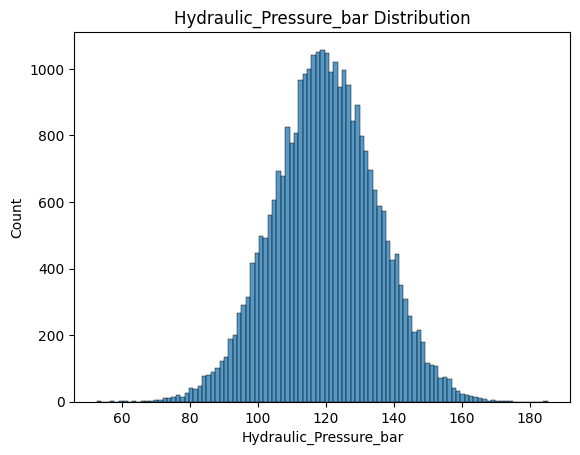

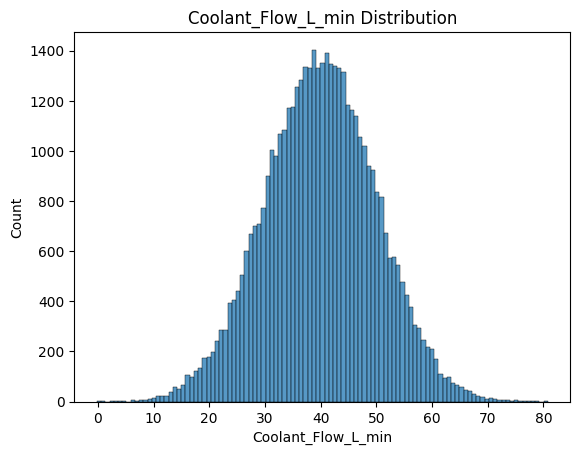

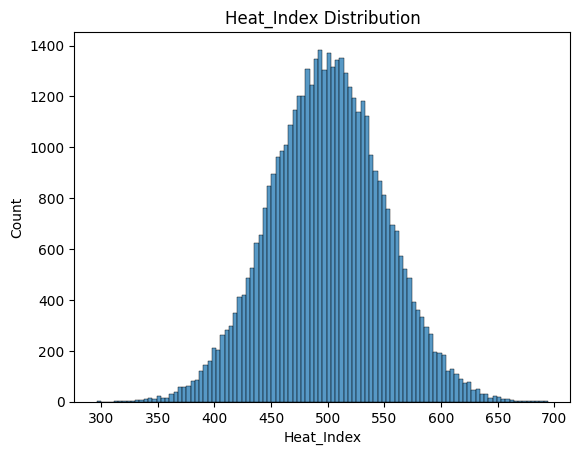

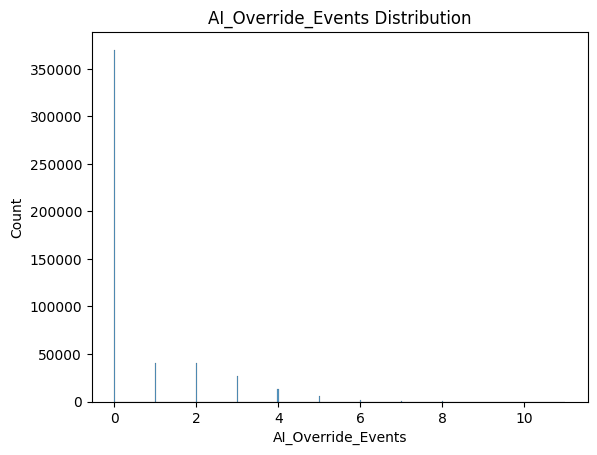

In [10]:

for col in df.select_dtypes(include=[np.number]):
    sns.histplot(df[col].dropna())
    plt.title(col + " Distribution")
    plt.show()
# Since the majority of the data has a normal distribution, no outliers are needed to be handled.


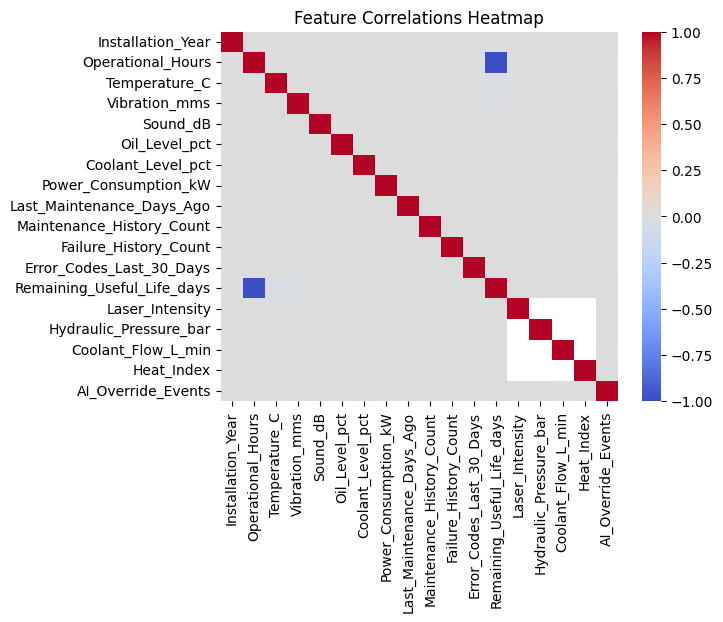

In [11]:
corr_map = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr_map, cmap='coolwarm', vmin=-1, center=0, vmax=1)
plt.title("Feature Correlations Heatmap")
plt.show()

# 2) Data Cleaning
---
#### Handeling:
- Duplicates
- Nulls
- Dropping Unnecessary Columns

#### 1) Duplicate rows

A) Checking for duplicate rows

In [12]:
df.drop('Machine_ID', axis=1).duplicated().sum()

np.int64(0)

#### 2) Null Values

A) Checking for Nulls

In [13]:
df.isna().sum()

Machine_ID                         0
Machine_Type                       0
Installation_Year                  0
Operational_Hours                  0
Temperature_C                      0
Vibration_mms                      0
Sound_dB                           0
Oil_Level_pct                      0
Coolant_Level_pct                  0
Power_Consumption_kW               0
Last_Maintenance_Days_Ago          0
Maintenance_History_Count          0
Failure_History_Count              0
AI_Supervision                     0
Error_Codes_Last_30_Days           0
Remaining_Useful_Life_days         0
Failure_Within_7_Days              0
Laser_Intensity               484844
Hydraulic_Pressure_bar        469660
Coolant_Flow_L_min            454376
Heat_Index                    454786
AI_Override_Events                 0
dtype: int64

B) Checking normal distribution for columns with Nulls

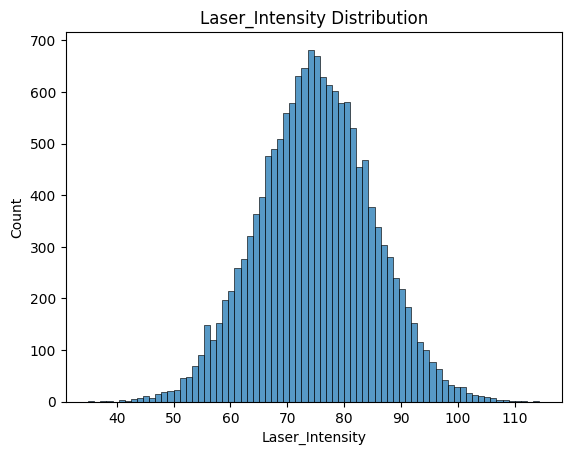

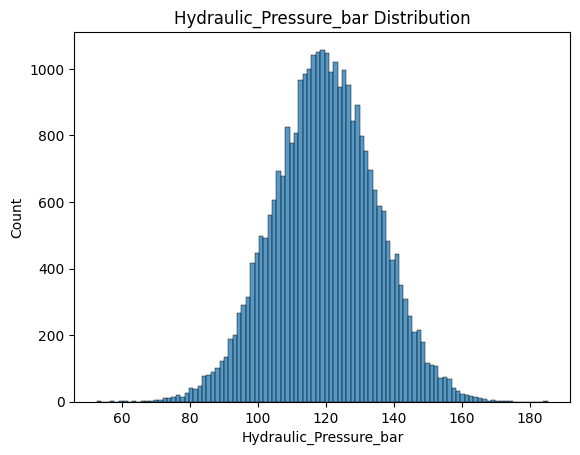

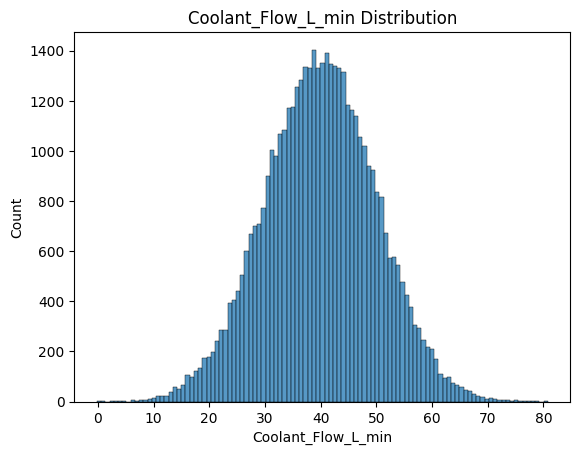

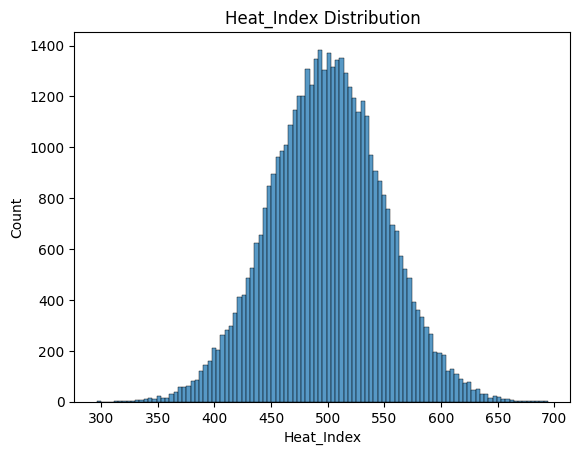

In [14]:
for col in ['Laser_Intensity', 'Hydraulic_Pressure_bar', 'Coolant_Flow_L_min', 'Heat_Index']:
    sns.histplot(df[col].dropna())
    plt.title(col + " Distribution")
    plt.show()
# Normal distribution for all columns.

C) Handeling Nulls

In [15]:
for col in ['Laser_Intensity', 'Hydraulic_Pressure_bar', 'Coolant_Flow_L_min', 'Heat_Index']:
    print(col, "has", (df[col] == 0).sum(), "rows with value 0")

Laser_Intensity has 0 rows with value 0
Hydraulic_Pressure_bar has 0 rows with value 0
Coolant_Flow_L_min has 0 rows with value 0
Heat_Index has 0 rows with value 0


In [16]:
for col in ['Laser_Intensity', 'Hydraulic_Pressure_bar', 'Coolant_Flow_L_min', 'Heat_Index']:
    df.fillna(0, inplace=True)

D) Assuring Null imputations done successfully

In [17]:
df.isna().sum()

Machine_ID                    0
Machine_Type                  0
Installation_Year             0
Operational_Hours             0
Temperature_C                 0
Vibration_mms                 0
Sound_dB                      0
Oil_Level_pct                 0
Coolant_Level_pct             0
Power_Consumption_kW          0
Last_Maintenance_Days_Ago     0
Maintenance_History_Count     0
Failure_History_Count         0
AI_Supervision                0
Error_Codes_Last_30_Days      0
Remaining_Useful_Life_days    0
Failure_Within_7_Days         0
Laser_Intensity               0
Hydraulic_Pressure_bar        0
Coolant_Flow_L_min            0
Heat_Index                    0
AI_Override_Events            0
dtype: int64

 3) Dropping unnecessary columns

In [18]:
df.drop(columns=['AI_Supervision', 'AI_Override_Events' ], inplace=True)


# 3) Feature Engineering
---

A) Flags


In [19]:

df['Flag_Critical_Fluid'] = np.where((df['Oil_Level_pct'] < df['Oil_Level_pct'].quantile(0.25)) | (df['Coolant_Level_pct'] < df['Coolant_Level_pct'].quantile(0.25)), 1, 0)
df['Flag_High_Stress'] = np.where((df['Temperature_C'] > df['Temperature_C'].quantile(0.75)) | (df['Vibration_mms'] > df['Vibration_mms'].quantile(0.75)), 1, 0)
df['Flag_Overdue_Maintenance'] = np.where(df['Last_Maintenance_Days_Ago'] > df['Last_Maintenance_Days_Ago'].quantile(0.75), 1, 0)


B) Years Segmentation

In [20]:
def assign_cohort(year):
    if year < 2000:
        return 'Legacy_Pre2000'
    elif 2000 <= year <= 2022:
        return 'Modern_Standard'
    else:
        return 'NextGen_FutureTech'

df['Machine_Tech_Cohort'] = df['Installation_Year'].apply(assign_cohort)

C) Errors

In [21]:

df['Maintenance_Decay_Factor'] = 1 - np.exp(-df['Last_Maintenance_Days_Ago'] / 90.0)
df['MTBF_Proxy'] = df['Operational_Hours'] / (df['Failure_History_Count'] + 1)
df['Maintenance_Inefficiency_Index'] = (df['Failure_History_Count'] + 1) / (df['Maintenance_History_Count'] + 1)

D) Efficiency Degradiations

In [22]:

eps = 1e-5
df['Specific_Vibration_Energy'] = (df['Vibration_mms']**2) / (np.log(abs(df['Power_Consumption_kW']) + 1) + eps)
df['Cumulative_Mechanical_Stress'] = df['Operational_Hours'] * np.sqrt(abs(df['Power_Consumption_kW'] * df['Temperature_C']))
type_temp_mean = df.groupby('Machine_Type')['Temperature_C'].transform('mean')
df['Thermal_Degradation_Index'] = np.exp(df['Temperature_C'] / (type_temp_mean + eps))

E) Multivariate Anomalies z-scores

In [23]:
sensor_cols = ['Temperature_C', 'Vibration_mms', 'Sound_dB', 'Power_Consumption_kW']

for col in sensor_cols:
    mean = df.groupby('Machine_Type')[col].transform('mean')
    std = df.groupby('Machine_Type')[col].transform('std') + eps
    df[f'{col}_Z'] = (df[col] - mean) / std

df['Multivariate_Anomaly_Score'] = np.sqrt(
    df['Temperature_C_Z']**2 +
    df['Vibration_mms_Z']**2 +
    df['Sound_dB_Z']**2 +
    df['Power_Consumption_kW_Z']**2
)

df.drop(columns=[f'{col}_Z' for col in sensor_cols], inplace=True)

Reviewing dataset after changes

In [24]:
df


,Machine_ID,Machine_Type,Installation_Year,Operational_Hours,Temperature_C,Vibration_mms,Sound_dB,Oil_Level_pct,Coolant_Level_pct,Power_Consumption_kW,...,Flag_High_Stress,Flag_Overdue_Maintenance,Machine_Tech_Cohort,Maintenance_Decay_Factor,MTBF_Proxy,Maintenance_Inefficiency_Index,Specific_Vibration_Energy,Cumulative_Mechanical_Stress,Thermal_Degradation_Index,Multivariate_Anomaly_Score
0,MC_000000,Mixer,2027,81769,73.43,12.78,83.72,36.76,68.74,84.95,...,1,0,NextGen_FutureTech,0.817316,13628.166667,1.200,36.671896,6.458135e+06,3.406865,1.587201
1,MC_000001,Industrial_Chiller,2032,74966,58.32,14.99,77.04,100.00,62.13,154.61,...,1,0,NextGen_FutureTech,0.779335,24988.666667,0.500,44.518317,7.118556e+06,2.648975,1.030154
2,MC_000002,Pick_and_Place,2003,94006,49.63,23.78,69.08,42.96,35.96,51.90,...,1,0,Modern_Standard,0.943112,47003.000000,1.000,142.497354,4.771022e+06,2.289355,3.137390
3,MC_000003,Vision_System,2007,76637,63.73,12.38,85.58,94.90,48.94,75.61,...,0,0,Modern_Standard,0.379840,38318.500000,0.400,35.324653,5.319858e+06,2.883220,1.493150
4,MC_000004,Shuttle_System,2016,20870,42.77,4.42,96.72,47.56,53.78,224.93,...,0,1,Modern_Standard,0.978602,6956.666667,0.600,3.604345,2.046990e+06,2.040890,2.862918
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499995,MC_499995,Vacuum_Packer,2011,14425,65.42,16.50,81.95,59.21,73.67,255.87,...,1,1,Modern_Standard,0.956428,3606.250000,0.800,49.066607,1.866297e+06,2.976636,2.014763
499996,MC_499996,Conveyor_Belt,2003,75501,44.83,12.88,64.94,73.69,29.25,198.37,...,0,0,Modern_Standard,0.900849,37750.500000,0.400,31.329367,7.119919e+06,2.110125,1.653235
499997,MC_499997,CMM,2039,19855,37.26,11.46,70.70,70.70,49.04,156.59,...,0,0,NextGen_FutureTech,0.871978,6618.333333,0.375,25.954827,1.516608e+06,1.860585,1.627517
499998,MC_499998,Dryer,2035,86823,67.72,16.76,77.45,97.00,15.40,132.33,...,1,0,NextGen_FutureTech,0.952377,28941.000000,0.750,57.409962,8.219065e+06,3.079175,1.486926


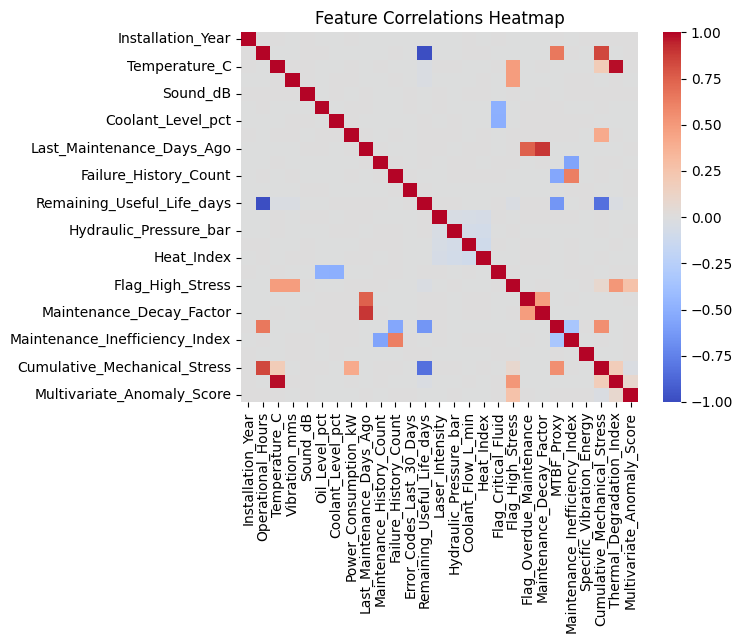

In [25]:

corr_map = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr_map, cmap='coolwarm', vmin=-1, center=0, vmax=1)
plt.title("Feature Correlations Heatmap")
plt.show()

# 4) Data Analysis
---

Machine types with has the highest average operational hours

In [26]:
df.groupby('Machine_Type')['Operational_Hours'].mean().sort_values(ascending=False).to_frame()
# Palletizer has the highest average operational hours.

,Operational_Hours
Machine_Type,
Palletizer,50337.610931
Crane,50331.072582
Grinder,50326.816601
Pump,50323.834121
Furnace,50261.320689
CNC_Mill,50244.288303
CNC_Lathe,50214.587247
Valve_Controller,50189.671800
Pick_and_Place,50168.053450


Relation between Failure History VS Power Consumption (kW)

In [27]:
df.groupby('Failure_History_Count')['Power_Consumption_kW'].sum().sort_index().to_frame()

,Power_Consumption_kW
Failure_History_Count,
0,10100555.05
1,20272310.68
2,20332832.88
3,13560131.21
4,6732036.15
5,2720676.47
6,901349.54
7,262181.77
8,61632.80


Modern VS old machinery power consumptions

In [28]:
df.groupby('Machine_Tech_Cohort')['Power_Consumption_kW'].sum().to_frame()


,Power_Consumption_kW
Machine_Tech_Cohort,
Modern_Standard,42177600.32
NextGen_FutureTech,32783480.02


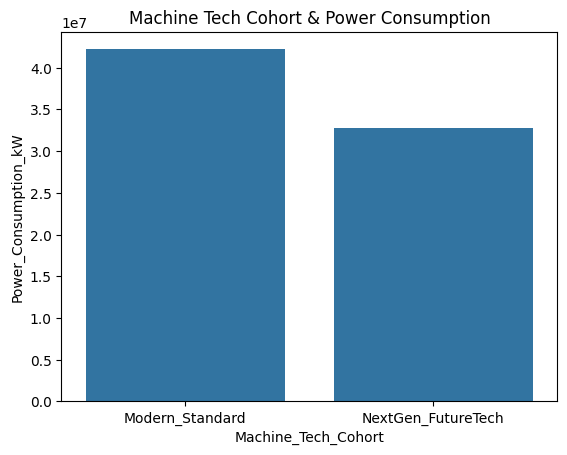

In [29]:
sns.barplot(df.groupby('Machine_Tech_Cohort')['Power_Consumption_kW'].sum())
plt.title("Machine Tech Cohort & Power Consumption")
plt.show()


Critical fluids percentage

In [30]:
critical_fluids = df['Flag_Critical_Fluid'].value_counts().to_frame()
critical_fluids['Percentage'] = (critical_fluids['count'] / critical_fluids['count'].sum())*100
critical_fluids

,count,Percentage
Flag_Critical_Fluid,,
0,281388,56.2776
1,218612,43.7224


# 5) Models
---

In [31]:
df

,Machine_ID,Machine_Type,Installation_Year,Operational_Hours,Temperature_C,Vibration_mms,Sound_dB,Oil_Level_pct,Coolant_Level_pct,Power_Consumption_kW,...,Flag_High_Stress,Flag_Overdue_Maintenance,Machine_Tech_Cohort,Maintenance_Decay_Factor,MTBF_Proxy,Maintenance_Inefficiency_Index,Specific_Vibration_Energy,Cumulative_Mechanical_Stress,Thermal_Degradation_Index,Multivariate_Anomaly_Score
0,MC_000000,Mixer,2027,81769,73.43,12.78,83.72,36.76,68.74,84.95,...,1,0,NextGen_FutureTech,0.817316,13628.166667,1.200,36.671896,6.458135e+06,3.406865,1.587201
1,MC_000001,Industrial_Chiller,2032,74966,58.32,14.99,77.04,100.00,62.13,154.61,...,1,0,NextGen_FutureTech,0.779335,24988.666667,0.500,44.518317,7.118556e+06,2.648975,1.030154
2,MC_000002,Pick_and_Place,2003,94006,49.63,23.78,69.08,42.96,35.96,51.90,...,1,0,Modern_Standard,0.943112,47003.000000,1.000,142.497354,4.771022e+06,2.289355,3.137390
3,MC_000003,Vision_System,2007,76637,63.73,12.38,85.58,94.90,48.94,75.61,...,0,0,Modern_Standard,0.379840,38318.500000,0.400,35.324653,5.319858e+06,2.883220,1.493150
4,MC_000004,Shuttle_System,2016,20870,42.77,4.42,96.72,47.56,53.78,224.93,...,0,1,Modern_Standard,0.978602,6956.666667,0.600,3.604345,2.046990e+06,2.040890,2.862918
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499995,MC_499995,Vacuum_Packer,2011,14425,65.42,16.50,81.95,59.21,73.67,255.87,...,1,1,Modern_Standard,0.956428,3606.250000,0.800,49.066607,1.866297e+06,2.976636,2.014763
499996,MC_499996,Conveyor_Belt,2003,75501,44.83,12.88,64.94,73.69,29.25,198.37,...,0,0,Modern_Standard,0.900849,37750.500000,0.400,31.329367,7.119919e+06,2.110125,1.653235
499997,MC_499997,CMM,2039,19855,37.26,11.46,70.70,70.70,49.04,156.59,...,0,0,NextGen_FutureTech,0.871978,6618.333333,0.375,25.954827,1.516608e+06,1.860585,1.627517
499998,MC_499998,Dryer,2035,86823,67.72,16.76,77.45,97.00,15.40,132.33,...,1,0,NextGen_FutureTech,0.952377,28941.000000,0.750,57.409962,8.219065e+06,3.079175,1.486926


In [32]:
df.drop(columns=[
    'Cumulative_Mechanical_Stress',
    'Specific_Vibration_Energy',
    'Machine_Tech_Cohort',
    'Maintenance_Decay_Factor',
    'MTBF_Proxy',
    'Maintenance_Inefficiency_Index',
    'Thermal_Degradation_Index',
    'Multivariate_Anomaly_Score'
], inplace=True)

In [33]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score 

## 5.1 Encoding and Mapping

In [34]:
from sklearn.preprocessing import LabelEncoder


def label_encode_column(series, known_values=None):
    values = series.astype(str)
    if known_values is None:
        known_values = sorted(values.dropna().unique())
    encoder = LabelEncoder()
    encoder.fit(list(known_values))
    return encoder.transform(values)


Machine_Types = [
    'Mixer', 'Industrial_Chiller', 'Pick_and_Place', 'Vision_System',
    'Shuttle_System', 'Labeler', 'Automated_Screwdriver', 'Shrink_Wrapper',
    'Laser_Cutter', 'CMM', 'CNC_Lathe', 'Dryer', 'Valve_Controller',
    'Furnace', 'Carton_Former', 'Hydraulic_Press', 'Compressor', 'AGV',
    'Robot_Arm', 'Conveyor_Belt', 'Forklift_Electric', 'Press_Brake',
    'Boiler', 'Vacuum_Packer', 'XRay_Inspector', 'Crane', '3D_Printer',
    'Palletizer', 'Grinder', 'CNC_Mill', 'Injection_Molder',
    'Heat_Exchanger', 'Pump'
]


df['Machine_Type'] = label_encode_column(df['Machine_Type'], Machine_Types)
df['Failure_Within_7_Days'] = label_encode_column(df['Failure_Within_7_Days'], ['True', 'False'])

Dropping # Machine_ID 

In [35]:
df = df.drop(['Machine_ID'], axis=1)
df

,Machine_Type,Installation_Year,Operational_Hours,Temperature_C,Vibration_mms,Sound_dB,Oil_Level_pct,Coolant_Level_pct,Power_Consumption_kW,Last_Maintenance_Days_Ago,...,Error_Codes_Last_30_Days,Remaining_Useful_Life_days,Failure_Within_7_Days,Laser_Intensity,Hydraulic_Pressure_bar,Coolant_Flow_L_min,Heat_Index,Flag_Critical_Fluid,Flag_High_Stress,Flag_Overdue_Maintenance
0,21,2027,81769,73.43,12.78,83.72,36.76,68.74,84.95,153,...,3,162.0,0,0.0,0.0,0.00,0.0,1,1,0
1,17,2032,74966,58.32,14.99,77.04,100.00,62.13,154.61,136,...,4,147.0,0,0.0,0.0,40.92,0.0,0,1,0
2,23,2003,94006,49.63,23.78,69.08,42.96,35.96,51.90,258,...,6,0.0,1,0.0,0.0,0.00,0.0,1,1,0
3,31,2007,76637,63.73,12.38,85.58,94.90,48.94,75.61,43,...,4,161.0,0,0.0,0.0,0.00,0.0,0,0,0
4,28,2016,20870,42.77,4.42,96.72,47.56,53.78,224.93,346,...,1,765.0,0,0.0,0.0,0.00,0.0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499995,29,2011,14425,65.42,16.50,81.95,59.21,73.67,255.87,282,...,0,820.0,0,0.0,0.0,0.00,0.0,0,1,1
499996,9,2003,75501,44.83,12.88,64.94,73.69,29.25,198.37,208,...,4,34.0,0,0.0,0.0,0.00,0.0,1,0,0
499997,4,2039,19855,37.26,11.46,70.70,70.70,49.04,156.59,185,...,4,815.0,0,0.0,0.0,0.00,0.0,0,0,0
499998,11,2035,86823,67.72,16.76,77.45,97.00,15.40,132.33,274,...,0,99.0,0,0.0,0.0,0.00,0.0,1,1,0


Import DecisionTree

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd


In [37]:
# Prepare a clean modeling dataset
model_df = df.copy()
model_df = model_df.drop(columns=['Machine_ID'], errors='ignore')

for col in model_df.select_dtypes(include=['object', 'bool']).columns:
    if col != 'Remaining_Useful_Life_days':
        model_df[col] = label_encode_column(model_df[col])

X = model_df.drop(columns=['Remaining_Useful_Life_days'])
y = model_df['Remaining_Useful_Life_days']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = DecisionTreeRegressor(random_state=42)
model.fit(X_train, y_train)

# Predict and evaluate
predictions = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print('R2 Score:', round(r2, 4))
print('RMSE:', round(rmse, 4))

R2 Score: 0.9432
RMSE: 68.8114


Feature Importances:
                  Feature  Importance
        Operational_Hours    0.972017
            Vibration_mms    0.003108
            Temperature_C    0.002870
                 Sound_dB    0.002445
     Power_Consumption_kW    0.002418
Last_Maintenance_Days_Ago    0.002294
            Oil_Level_pct    0.002267
        Coolant_Level_pct    0.002165
    Failure_Within_7_Days    0.001918
        Installation_Year    0.001842
             Machine_Type    0.001700
Maintenance_History_Count    0.001214
 Error_Codes_Last_30_Days    0.000999
    Failure_History_Count    0.000858
         Flag_High_Stress    0.000594
       Coolant_Flow_L_min    0.000335
               Heat_Index    0.000334
   Hydraulic_Pressure_bar    0.000260
          Laser_Intensity    0.000147
      Flag_Critical_Fluid    0.000143
 Flag_Overdue_Maintenance    0.000074


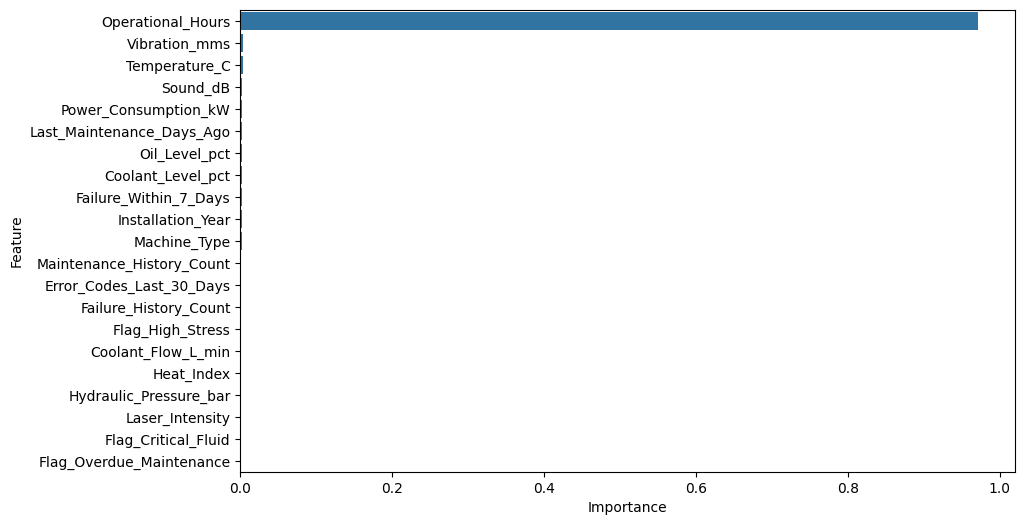

In [38]:
print('Feature Importances:')
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)

print(importance_df.to_string(index=False))

In [39]:
from sklearn.linear_model import LinearRegression


In [40]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

y_pred = linear_model.predict(X_test)

In [41]:
train_r2 = linear_model.score(X_train, y_train)
test_r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

metrics = pd.DataFrame({
    "Metric": ["Training R²", "Testing R²", "MSE", "RMSE"],
    "Value": [train_r2, test_r2, mse, rmse]
})

display(metrics)

print(f"The model explains approximately {test_r2 * 100:.2f}% of the variation in the test target.")


,Metric,Value
0,Training R²,0.971510
1,Testing R²,0.971437
2,MSE,2380.224466
3,RMSE,48.787544


The model explains approximately 97.14% of the variation in the test target.


<Axes: xlabel='Importance', ylabel='Feature'>

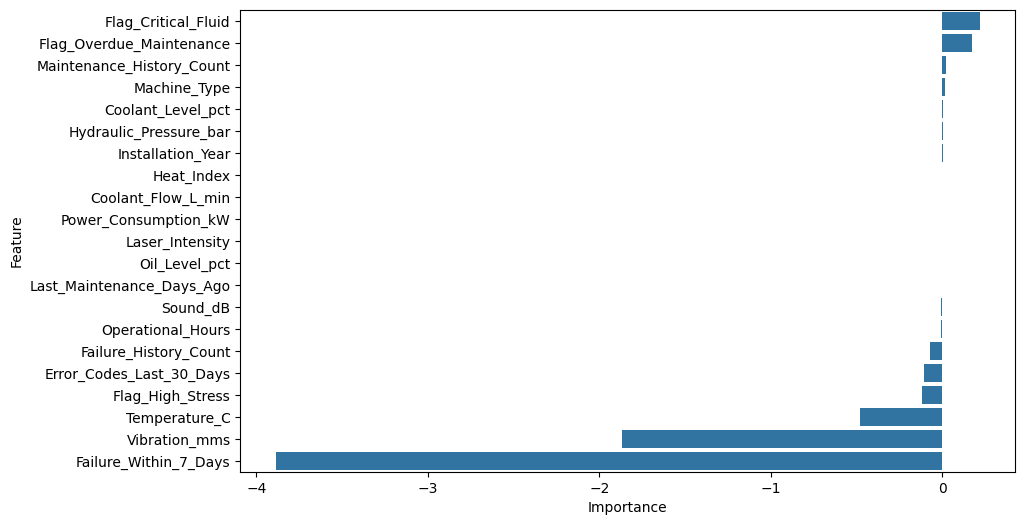

In [42]:
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': linear_model.coef_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importances)

In [43]:
from sklearn.ensemble import RandomForestRegressor


In [44]:

model = RandomForestRegressor(n_estimators=6, random_state=42)
model.fit(X_train, y_train)
y_predict = model.predict(X_test)



Accuracy: 0.9674717839771819


<Axes: xlabel='Importance', ylabel='Feature'>

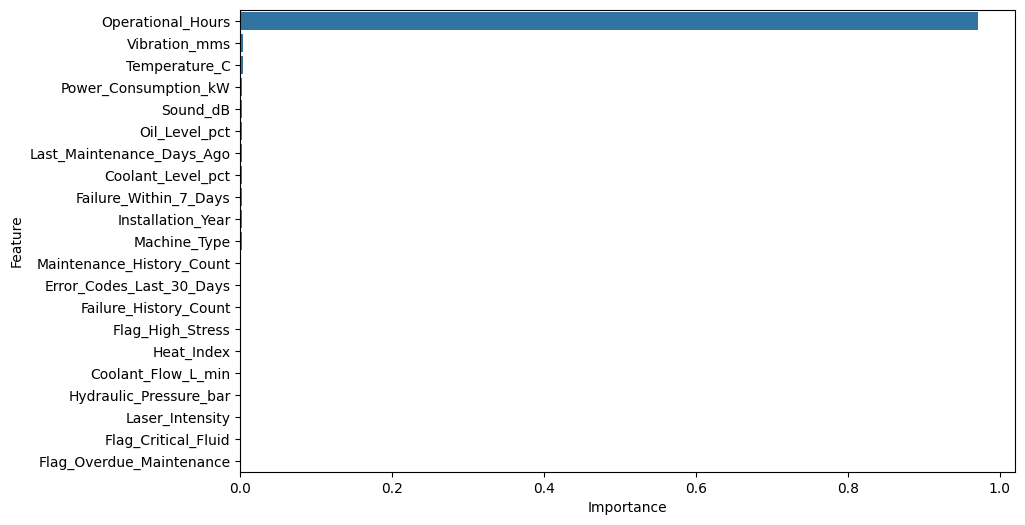

In [45]:
accuracy_score = model.score(X_test, y_test)
print("Accuracy:", accuracy_score)
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importances)

In [46]:

import tensorflow as tf
from tensorflow.keras.optimizers import Adam
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

import numpy as np

In [47]:
X_train_np = X_train.to_numpy(dtype=np.float32)
X_test_np = X_test.to_numpy(dtype=np.float32)
y_train_np = y_train.to_numpy(dtype=np.float32).reshape(-1, 1)
y_test_np = y_test.to_numpy(dtype=np.float32).reshape(-1, 1)

model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train_np.shape[1],)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1)
])

model.compile(optimizer='Adam', loss='mse', metrics=['mae'])

model.fit(X_train_np, y_train_np, epochs=6, batch_size=256, verbose=0)

test_loss, test_mae = model.evaluate(X_test_np, y_test_np, verbose=0)
print(f"Test MAE: {test_mae:.4f}")
test_pred = model.predict(X_test_np).reshape(-1)
test_r2 = r2_score(y_test_np.reshape(-1), test_pred)
print(f"Test R²: {test_r2:.4f}")

c:\Users\Ahmed\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test MAE: 42.5592
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 3s 985us/step
Test R²: 0.9664
